# Proyecto 2do Parcial: Clasificación de Imágenes Médicas
**Autor:** Kristopher Vela Domínguez

### 1. Configuración y Selección del Dataset
Para este proyecto utilizaremos el dataset **BloodMNIST**, compuesto por imágenes a color (RGB) de $28 \times 28$ píxeles, categorizadas en 8 clases diferentes de células sanguíneas. 

Se generarán particiones de entrenamiento, validación y prueba para evaluar correctamente el rendimiento de los modelos.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {device}")

# 2. Selección del Dataset: BloodMNIST
info = INFO['bloodmnist']
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])

# Transformaciones básicas (Resolución nativa 28x28)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 3. DataLoaders (CORRECCIÓN: drop_last=True en train_loader)
batch_size = 64
train_loader = DataLoader(DataClass(split='train', transform=transform, download=True), batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(DataClass(split='val', transform=transform, download=True), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(DataClass(split='test', transform=transform, download=True), batch_size=batch_size, shuffle=False)

Dispositivo de entrenamiento: cpu


### 2. Métricas de Desempeño
Para la evaluación final, utilizaremos las siguientes fórmulas métricas basadas en la matriz de confusión (Verdaderos Positivos, Falsos Positivos, Verdaderos Negativos, Falsos Negativos):

* **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$ (Porcentaje general de aciertos)
* **Precisión:** $\frac{TP}{TP + FP}$ (Exactitud de las predicciones positivas)
* **Recall:** $\frac{TP}{TP + FN}$ (Capacidad de encontrar todos los positivos reales)
* **F1-Score:** $2 \times \frac{Precision \times Recall}{Precision + Recall}$ (Media armónica)

### 3. Función de Entrenamiento Optimizado
Para evitar código redundante, definimos una función que encapsula el ciclo de entrenamiento y validación. Esto nos permitirá entrenar múltiples modelos de forma limpia y eficiente.

In [11]:
# Función reutilizable para entrenar cualquier modelo
def entrenar_modelo(modelo, optimizador, criterio, nombre_modelo, epochs=10):
    historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print(f"\n--- Iniciando entrenamiento de {nombre_modelo} ---")
    for epoch in range(epochs):
        # Fase de Entrenamiento
        modelo.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, targets in tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}"):
            inputs, targets = inputs.to(device), targets.squeeze(1).long().to(device)
            optimizador.zero_grad()
            outputs = modelo(inputs)
            loss = criterio(outputs, targets)
            loss.backward()
            optimizador.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
        historial['train_loss'].append(running_loss / len(train_loader))
        historial['train_acc'].append(100. * correct / total)
        
        # Fase de Validación
        modelo.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.squeeze(1).long().to(device)
                outputs = modelo(inputs)
                val_loss += criterio(outputs, targets).item()
                _, predicted = outputs.max(1)
                total_val += targets.size(0)
                correct_val += predicted.eq(targets).sum().item()
                
        historial['val_loss'].append(val_loss / len(val_loader))
        historial['val_acc'].append(100. * correct_val / total_val)
        
    return historial

### 4. Arquitectura Propia (KrisNET) vs ResNet-50
Se define e instancia **KrisNET** (CNN de 2 bloques convolucionales) y se configura **ResNet-50** usando Transfer Learning (congelando capas base).

In [12]:
from torchvision.models import resnet50, ResNet50_Weights

# --- A) KRISNET (Diseño Propio) ---
class KrisNET(nn.Module):
    def __init__(self, num_classes=8):
        super(KrisNET, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

modelo_kris = KrisNET(num_classes=n_classes).to(device)
opt_kris = optim.Adam(modelo_kris.parameters(), lr=0.001)

# --- B) RESNET-50 (Transfer Learning) ---
modelo_resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
for param in modelo_resnet.parameters():
    param.requires_grad = False # Congelamos base

modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, n_classes)
modelo_resnet = modelo_resnet.to(device)
opt_resnet = optim.Adam(modelo_resnet.fc.parameters(), lr=0.001)

# --- ENTRENAMIENTO SECUENCIAL (Uso de nuestra función) ---
criterion = nn.CrossEntropyLoss()
historial_kris = entrenar_modelo(modelo_kris, opt_kris, criterion, "KrisNET", epochs=10)
historial_res = entrenar_modelo(modelo_resnet, opt_resnet, criterion, "ResNet-50", epochs=10)


--- Iniciando entrenamiento de KrisNET ---


Época 10/10: 100%|██████████| 186/186 [00:08<00:00, 21.95it/s]



--- Iniciando entrenamiento de ResNet-50 ---


Época 10/10: 100%|██████████| 186/186 [01:08<00:00,  2.70it/s]


### 5. Gráficas de Convergencia
Análisis visual del comportamiento de la Pérdida (Loss) y la Exactitud (Accuracy) de ambos modelos durante las 10 épocas.

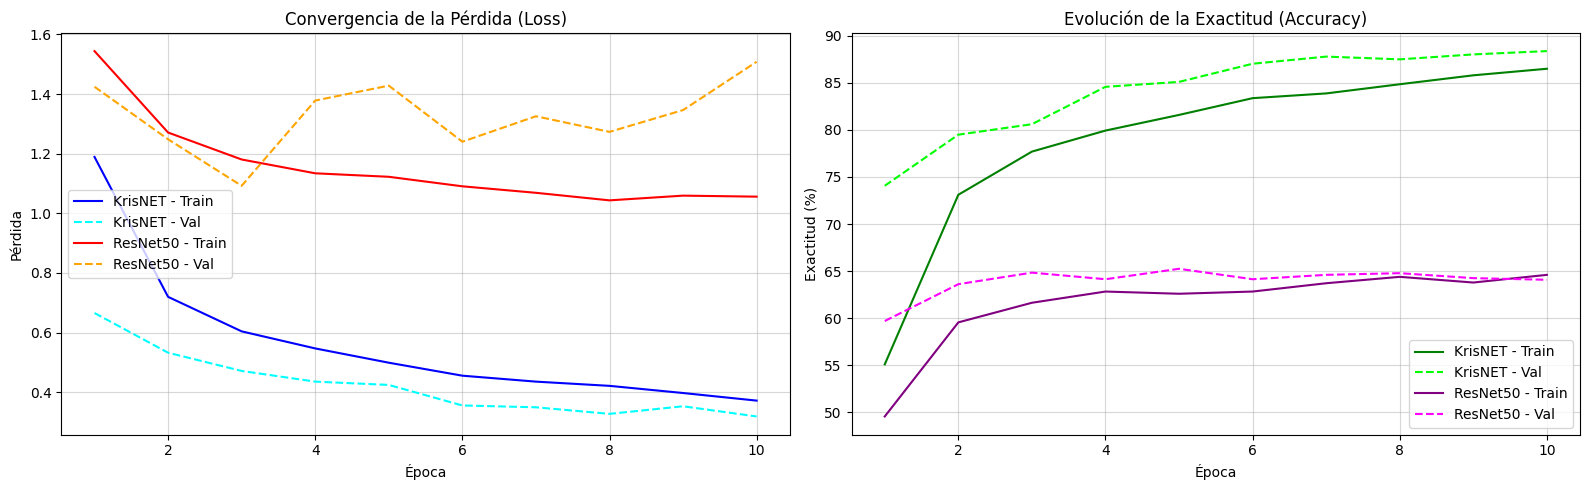

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
epocas = range(1, 11)

# Gráfica de Loss
ax1.plot(epocas, historial_kris['train_loss'], label='KrisNET - Train', color='blue', linestyle='-')
ax1.plot(epocas, historial_kris['val_loss'], label='KrisNET - Val', color='cyan', linestyle='--')
ax1.plot(epocas, historial_res['train_loss'], label='ResNet50 - Train', color='red', linestyle='-')
ax1.plot(epocas, historial_res['val_loss'], label='ResNet50 - Val', color='orange', linestyle='--')
ax1.set_title('Convergencia de la Pérdida (Loss)')
ax1.set_xlabel('Época'); ax1.set_ylabel('Pérdida')
ax1.legend(); ax1.grid(True, alpha=0.5)

# Gráfica de Accuracy
ax2.plot(epocas, historial_kris['train_acc'], label='KrisNET - Train', color='green', linestyle='-')
ax2.plot(epocas, historial_kris['val_acc'], label='KrisNET - Val', color='lime', linestyle='--')
ax2.plot(epocas, historial_res['train_acc'], label='ResNet50 - Train', color='purple', linestyle='-')
ax2.plot(epocas, historial_res['val_acc'], label='ResNet50 - Val', color='magenta', linestyle='--')
ax2.set_title('Evolución de la Exactitud (Accuracy)')
ax2.set_xlabel('Época'); ax2.set_ylabel('Exactitud (%)')
ax2.legend(); ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### 6. Reporte Final de Métricas (Testing)
Validación de las métricas teóricas propuestas aplicadas sobre el conjunto de datos de Prueba, el cual contiene imágenes que ninguno de los dos modelos ha visto antes.

In [15]:
def evaluar_metricas_finales(modelo, nombre):
    modelo.eval()
    all_targets, all_preds = [], []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.squeeze(1).long().to(device)
            outputs = modelo(inputs)
            _, predicted = outputs.max(1)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    
    print(f"--- Desempeño Final: {nombre} ---")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"Precisión : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

evaluar_metricas_finales(modelo_kris, "KrisNET")
evaluar_metricas_finales(modelo_resnet, "ResNet-50")

--- Desempeño Final: KrisNET ---
Accuracy  : 87.49%
Precisión : 0.8658
Recall    : 0.8400
F1-Score  : 0.8502

--- Desempeño Final: ResNet-50 ---
Accuracy  : 64.81%
Precisión : 0.6238
Recall    : 0.6037
F1-Score  : 0.6110

